<a href="https://colab.research.google.com/github/DevShah2k6/PythonWork/blob/Pytorch-Projects/Pytorch_Company_Project(Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchmetrics

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torchvision
from torch import nn
from torchmetrics import Accuracy,ConfusionMatrix
from tqdm.auto import tqdm

In [ ]:
smmh_df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")

In [ ]:
smmh_df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [ ]:
#Checking for Null Values
smmh_df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
#Checking for Duplicates Values
smmh_df.duplicated().sum()

np.int64(0)

In [ ]:
#Shwoing the First Five Rows
smmh_df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
#Showing last Five Rows
smmh_df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [ ]:

smmh_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
smmh_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0
depression_label,1200.0,0.025833,0.158704,0.0,0.0,0.00,0.00,1.0


In [ ]:
#Showing Relation Betwen Daily social media hours vs Strees level(target Feature)vs Screen time before sleep
smmh_df[["screen_time_before_sleep","stress_level","daily_social_media_hours"]].corr()

,screen_time_before_sleep,stress_level,daily_social_media_hours
screen_time_before_sleep,1.000000,-0.008650,0.035777
stress_level,-0.008650,1.000000,0.030698
daily_social_media_hours,0.035777,0.030698,1.000000


# **Visulization Part Begins**

([<matplotlib.axis.XTick at 0x79f3b8adc350>],
 [Text(1, 0, 'Social Media Hours')])

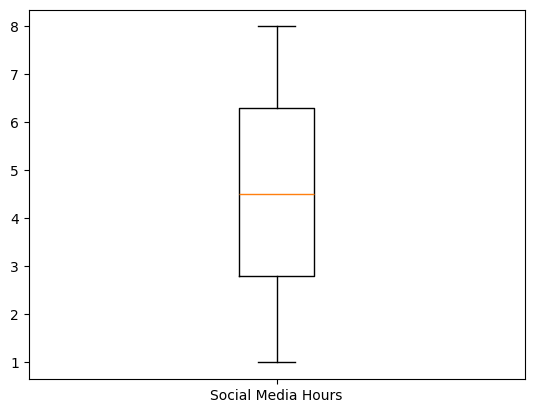

In [ ]:
plt.boxplot(x = smmh_df["daily_social_media_hours"])
plt.xticks([1],["Social Media Hours"])

In [ ]:
social_interaction = smmh_df["social_interaction_level"].value_counts(normalize=True)*100

Text(0.5, 1.0, 'Social Interaction Level Distribution')

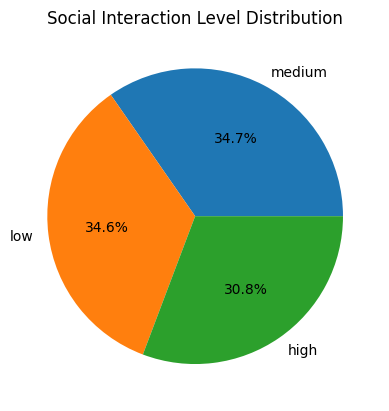

In [ ]:
plt.pie(social_interaction.values,labels = social_interaction.index,autopct = "%1.1f%%")
plt.title("Social Interaction Level Distribution")

In [ ]:
platform_usage = smmh_df["platform_usage"].value_counts(normalize=True)*100

Text(0.5, 1.0, 'Platform Usage Distribution')

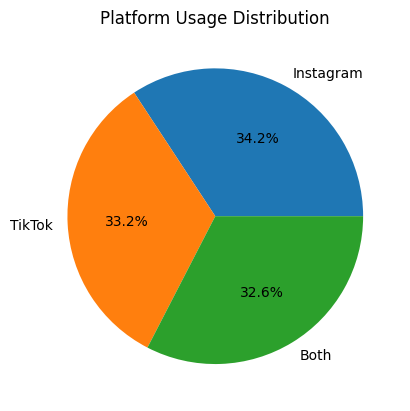

In [ ]:
plt.pie(platform_usage.values,labels = platform_usage.index,autopct = "%1.1f%%")
plt.title("Platform Usage Distribution")

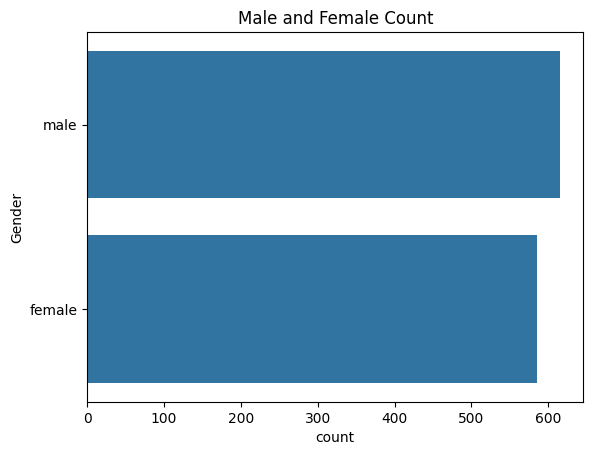

In [ ]:
sns.countplot(smmh_df["gender"])
plt.xlabel("count")
plt.ylabel("Gender")
plt.title("Male and Female Count")
plt.show()

In [ ]:
depression_status = smmh_df["depression_label"].value_counts(normalize=True)*100

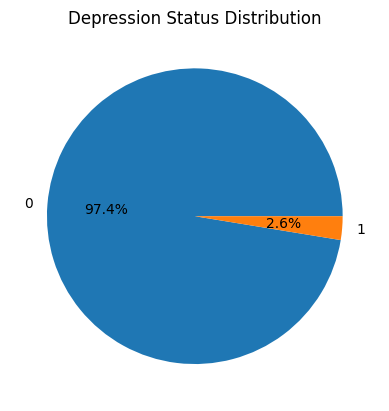

In [ ]:
plt.pie(depression_status.values,labels = depression_status.index,autopct = "%1.1f%%")
plt.title("Depression Status Distribution")
plt.show()

# **Preporcessing Part**

In [ ]:
smmh_df["gender"] = smmh_df["gender"].map({"male":0,"female":1})

In [ ]:
smmh_df["social_interaction_level"] = smmh_df["social_interaction_level"].map({"low":0,"medium":1,"high":2})

In [ ]:
smmh_df["social_interaction_level"]

,social_interaction_level
0,0
1,2
2,2
3,1
4,1
...,...
1195,0
1196,2
1197,2
1198,2


In [ ]:
platform_dummies = pd.get_dummies(smmh_df["platform_usage"]).astype(int)

In [ ]:
smmh_df = pd.concat([smmh_df,platform_dummies],axis=1)

In [ ]:
smmh_df.drop("platform_usage",axis=1,inplace=True)

In [ ]:
smmh_df

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,Both,Instagram,TikTok
0,14,0,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,0,1,0
1,19,1,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,0,0,1
2,17,1,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,0,1,0
3,15,0,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,0,0,1
4,15,1,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,1,6.8,6.6,2.0,2.76,1.0,0,3,4,4,0,0,1,0
1196,16,0,2.3,8.0,1.9,2.12,0.4,2,7,4,4,0,1,0,0
1197,14,1,1.7,8.7,0.7,3.98,0.8,2,1,1,1,0,1,0,0
1198,15,0,3.9,8.5,2.1,3.19,0.6,2,7,9,9,0,1,0,0


In [ ]:
x = smmh_df.drop("social_interaction_level",axis=1)
y = smmh_df["social_interaction_level"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
type(x_train),type(y_train)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [ ]:
type(y_train),type(y_test)

(pandas.core.series.Series, pandas.core.series.Series)

# **Converting the Dataframe into Tensor**

In [ ]:
x_train_tensor = torch.tensor(x_train.values,dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.long)

In [ ]:
type(x_train_tensor),type(x_test_tensor)


(torch.Tensor, torch.Tensor)

In [ ]:
type(y_train_tensor),type(y_test_tensor)

(torch.Tensor, torch.Tensor)

# **Deep Learning Pipeline Starts**

In [ ]:
#Class making and weigh and bias all things are done here
class SocialMediaImpact(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Sequential(
        nn.Linear(in_features=14,out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128,out_features=32),
        nn.ReLU()
    )
    self.layer_2 = nn.Sequential(
        nn.Linear(in_features=32,out_features=16),
        nn.ReLU(),
        nn.Linear(in_features=16,out_features=3)
    )
  def forward(self,x):
    return self.layer_2(self.layer_1(x))

In [ ]:
model = SocialMediaImpact()

In [ ]:
print(y_train_tensor.dtype)
print(torch.unique(y_train_tensor))

torch.int64
tensor([0, 1, 2])


# **Loss Function and Optimizer Object Initalized**

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(params = model.parameters(),lr=0.001)

In [ ]:
x_train_tensor.shape,y_train_tensor.shape

(torch.Size([960, 14]), torch.Size([960]))

In [ ]:
x_test_tensor.shape,y_test_tensor.shape

(torch.Size([240, 14]), torch.Size([240]))

# **Training and Testing Loop Begins**

In [ ]:
def train_loop(model:torch.nn.Module,loss_fn,optimizer):
  #training the model
  model.train()

  y_logits_train = model(x_train_tensor).squeeze(1)

  train_loss = loss_fn(y_logits_train,y_train_tensor)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  print(f"Train Loss: {train_loss}")
  acc = Accuracy(task="multiclass", num_classes=3)
  result_acc_train = acc(y_logits_train,y_train_tensor)
  print(f"Train Accuracy: {result_acc_train}")

  return y_logits_train,train_loss,result_acc_train

In [ ]:
def test_loop(model:torch.nn.Module,loss_fn,optimizer):
  model.eval()
  with torch.inference_mode():
    y_logits_test = model(x_test_tensor).squeeze(1)
    test_loss = loss_fn(y_logits_test,y_test_tensor)
    print(f"Test Loss: {test_loss}")

    acc_test = Accuracy(task="multiclass", num_classes=3)
    result_acc_test = acc_test(y_logits_test,y_test_tensor)
    print(f"Test Accuracy: {result_acc_test}")
  return y_logits_test,test_loss,result_acc_test

In [ ]:
NUM_EPOCHS = 100
training_loss=[]
testing_loss=[]
training_acc = []
testing_acc = []
for epoch in tqdm(range(NUM_EPOCHS)):
  logits_train,train_loss,train_acc = train_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
  training_loss.append(train_loss)
  training_acc.append(train_acc)
  logits_test,test_loss,test_acc = test_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
  testing_loss.append(test_loss)
  testing_acc.append(test_acc)

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 1.1091700792312622
Train Accuracy: 0.29895833134651184
Test Loss: 1.105232834815979
Test Accuracy: 0.2666666805744171
Train Loss: 1.1032493114471436
Train Accuracy: 0.29895833134651184
Test Loss: 1.1015911102294922
Test Accuracy: 0.34166666865348816
Train Loss: 1.1014176607131958
Train Accuracy: 0.3322916626930237
Test Loss: 1.1002928018569946
Test Accuracy: 0.36250001192092896
Train Loss: 1.0997436046600342
Train Accuracy: 0.3395833373069763
Test Loss: 1.1005791425704956
Test Accuracy: 0.34583333134651184
Train Loss: 1.098988652229309
Train Accuracy: 0.3479166626930237
Test Loss: 1.1014724969863892
Test Accuracy: 0.3291666805744171
Train Loss: 1.0988876819610596
Train Accuracy: 0.35624998807907104
Test Loss: 1.1012170314788818
Test Accuracy: 0.3375000059604645
Train Loss: 1.0984574556350708
Train Accuracy: 0.36770832538604736
Test Loss: 1.1003124713897705
Test Accuracy: 0.3375000059604645
Train Loss: 1.097617268562317
Train Accuracy: 0.3645833432674408
Test Loss: 1.0995482

In [ ]:
def metrics_eval_train_test(y_logits_train,y_logits_test):
  acc = Accuracy(task="multiclass", num_classes=3)
  result_acc_train = acc(y_logits_train,y_train_tensor)
  print(f"Train Accuracy: {result_acc_train}")

  acc_test = Accuracy(task="multiclass", num_classes=3)
  result_acc_test = acc_test(y_logits_test,y_test_tensor)
  print(f"Test Accuracy: {result_acc_test}")
  return result_acc_train,result_acc_test
# metrics_eval(logits_train,logits_test)

In [ ]:

train_acc,test_acc = metrics_eval_train_test(logits_train,logits_test)
train_acc

Train Accuracy: 0.49687498807907104
Test Accuracy: 0.3375000059604645


tensor(0.4969)

In [ ]:
#prediction

model.eval()
with torch.inference_mode():
  y_pred = model(x_test_tensor)
  y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)


In [ ]:
type(y_pred_class),type(y_test_tensor)

(torch.Tensor, torch.Tensor)

In [ ]:
def final_acc():
  acc = Accuracy(task="multiclass", num_classes=3)
  result_acc = acc(y_pred_class,y_test_tensor)
  conf = ConfusionMatrix(task="multiclass",num_classes=3)
  final_matrix = conf(y_pred_class,y_test_tensor)
  print(f"Accuracy:{result_acc} | \nConfusion Matrix:{final_matrix}")
  sns.heatmap(final_matrix.numpy(),annot=True)
  return final_matrix

Accuracy:0.3375000059604645 | 
Confusion Matrix:tensor([[32, 42, 11],
        [34, 41,  7],
        [28, 37,  8]])


tensor([[32, 42, 11],
        [34, 41,  7],
        [28, 37,  8]])

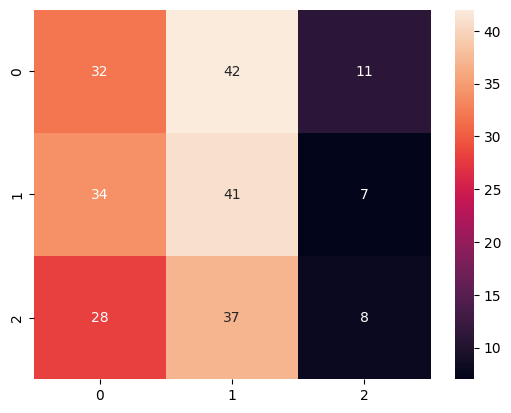

In [ ]:
final_acc()

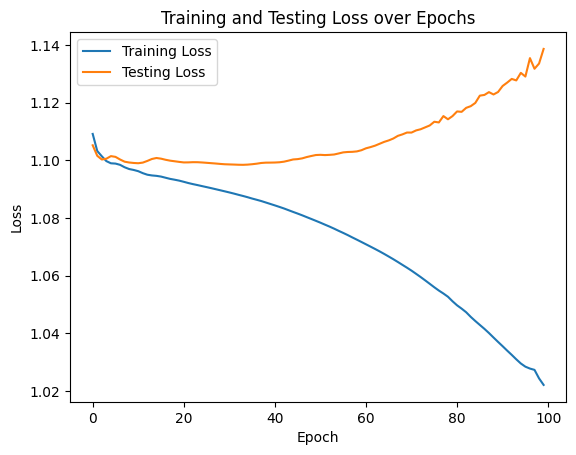

In [ ]:
plt.plot(range(NUM_EPOCHS), [loss.item() for loss in training_loss], label="Training Loss")
plt.plot(range(NUM_EPOCHS), [loss.item() for loss in testing_loss], label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss over Epochs")
plt.legend()
plt.show()

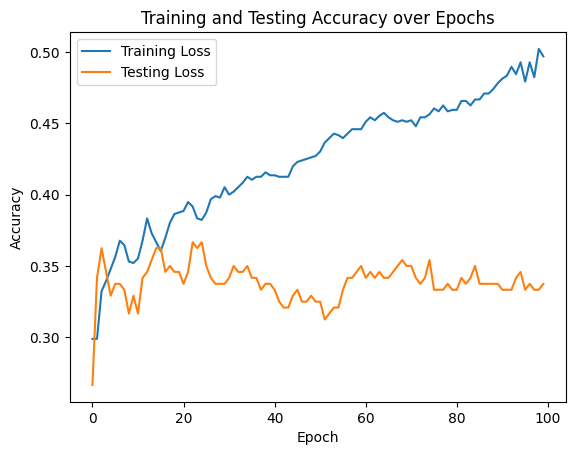

In [ ]:
plt.plot(range(NUM_EPOCHS), [train_acc.item() for train_acc in training_acc], label="Training Loss")
plt.plot(range(NUM_EPOCHS), [test_acc.item() for test_acc in testing_acc], label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy over Epochs")
plt.legend()
plt.show()